Data Load

In [105]:
import pandas as pd

# Load the dataset from the URL below
url = "https://raw.githubusercontent.com/DataStorageSchulich/DataStorage/refs/heads/main/dataset_lm.csv"
data = pd.read_csv(url)


Part A: OLS Model

In [106]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

# Define dependent variable
y = data['Dependent Var']

# Define explanatory variables from #1 to #15
X = data[[f'Explanatory Var #{i}' for i in range(1, 16)]]

# Add a constant term for the intercept
X = sm.add_constant(X)

# Run OLS model
ols_model = OLS(y, X).fit()

# Show summary
ols_summary = ols_model.summary()
print(ols_summary)

                            OLS Regression Results                            
Dep. Variable:          Dependent Var   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.125e+30
Date:                Sun, 13 Oct 2024   Prob (F-statistic):               0.00
Time:                        21:51:18   Log-Likelihood:                 11936.
No. Observations:                 422   AIC:                        -2.384e+04
Df Residuals:                     406   BIC:                        -2.378e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.0000   1

Part B: GLS Model Using Error Terms

In [107]:
import numpy as np
from statsmodels.regression.linear_model import OLS, GLS
from statsmodels.tools.tools import add_constant

# y (dependent variable) and X (independent variables) are defined already
# Add constant to independent variables
X = add_constant(X)

# Fit an OLS model
ols_model = OLS(y, X).fit()

# Get residuals from the OLS model
errors = ols_model.resid

# Calculate standard deviation and autocorrelations
std_dev_errors = np.std(errors)
autocorr_lag1 = np.corrcoef(errors[:-1], errors[1:])[0, 1]
autocorr_lag2 = np.corrcoef(errors[:-2], errors[2:])[0, 1]
autocorr_lag3 = np.corrcoef(errors[:-3], errors[3:])[0, 1]

print(f'Standard Deviation of Errors: {std_dev_errors}')
print(f'Autocorrelation (lag 1): {autocorr_lag1}')
print(f'Autocorrelation (lag 2): {autocorr_lag2}')
print(f'Autocorrelation (lag 3): {autocorr_lag3}')

# Now fit a GLS model (assuming autocorrelation exists)
gls_model = GLS(y, X).fit()

# Show GLS summary
gls_summary = gls_model.summary()
print(gls_summary)

Standard Deviation of Errors: 5.555415584649497e-14
Autocorrelation (lag 1): 0.14266367724760337
Autocorrelation (lag 2): 0.00506883595593113
Autocorrelation (lag 3): -0.04787405830765893
                            GLS Regression Results                            
Dep. Variable:          Dependent Var   R-squared:                       1.000
Model:                            GLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.125e+30
Date:                Sun, 13 Oct 2024   Prob (F-statistic):               0.00
Time:                        21:51:18   Log-Likelihood:                 11936.
No. Observations:                 422   AIC:                        -2.384e+04
Df Residuals:                     406   BIC:                        -2.378e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                      

Part C: Lasso Model with Training and Test Split

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Run Lasso model with alpha=1
lasso_model = Lasso(alpha=1)
lasso_model.fit(X_train, y_train)

# Estimate coefficients
lasso_coefficients = lasso_model.coef_
print(f'Lasso Coefficients: {lasso_coefficients}')

# Calculate mean absolute percentage error (MAPE)
y_pred = lasso_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'Mean Absolute Percentage Error (MAPE): {mape}')

# Find approximate value for alpha to minimize MAPE
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-4, 1, 50)
lasso_grid = GridSearchCV(Lasso(), {'alpha': alphas}, scoring='neg_mean_absolute_percentage_error', cv=5)
lasso_grid.fit(X_train, y_train)

best_alpha = lasso_grid.best_params_['alpha']
print(f'Best alpha value: {best_alpha}')

Lasso Coefficients: [ 0.          1.26972628  1.68394638  2.02626245  2.08756512 -0.91746375
 -0.          0.         -0.          0.         -0.          0.01314162
  0.         -0.          0.         -0.03617731]
Mean Absolute Percentage Error (MAPE): 0.04432190198291582
Best alpha value: 0.0001


Part D: Demand Forecasting

                               SARIMAX Results                                
Dep. Variable:            real_demand   No. Observations:                   18
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -72.248
Date:                Sun, 13 Oct 2024   AIC                            150.496
Time:                        21:51:18   BIC                            153.167
Sample:                             0   HQIC                           150.864
                                 - 18                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
advance_demand     0.4383      0.070      6.276      0.000       0.301       0.575
ar.L1              0.9884      0.037     26.616      0.000       0.916       1.061
sigma2           145.4817     52.162

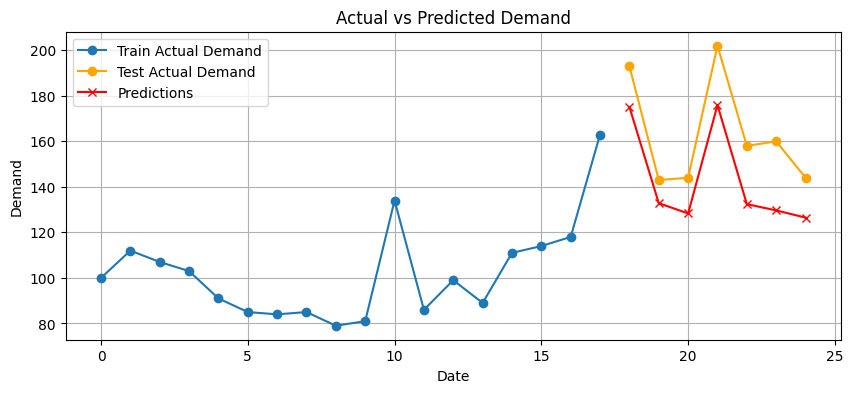

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Data Load
advance_demand = [71, 30, 75, 64, 41, 51, 42, 51, 57, 49, 134, 52, 99, 56, 81, 79, 73, 163, 193, 99, 91, 202, 105, 101, 96]
real_demand = [100, 112, 107, 103, 91, 85, 84, 85, 79, 81, 134, 86, 99, 89, 111, 114, 118, 163, 193, 143, 144, 202, 158, 160, 144]
data = pd.DataFrame({'advance_demand': advance_demand, 'real_demand': real_demand})

# Use the first 18 months for training and the remaining for testing
train_size = 18

train_advance = data['advance_demand'][:train_size]
train_real = data['real_demand'][:train_size]
test_advance = data['advance_demand'][train_size:]
test_real = data['real_demand'][train_size:]

# Exogenous variable is train_advance. SARIMAX model.
model = SARIMAX(train_real, exog=train_advance, order=(1,0,0))
model_fit = model.fit(disp=False)

# Print the model summary for diagnostics
print(model_fit.summary())

# Predictions on test data
predictions = model_fit.predict(start=len(train_real), end=len(train_real) + len(test_real) - 1, exog=test_advance)

# Calculate metrics
mae = mean_absolute_error(test_real, predictions)
mse = mean_squared_error(test_real, predictions)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')

# Create the results table
results_df = pd.DataFrame({
    'Month #': np.arange(train_size + 1, train_size + 1 + len(test_real)),
    'Advance Demand': test_advance,
    'Actual Demand': test_real,
    'Predicted Demand': predictions,
    'Delta': test_real - predictions
})

# Display the results table
print(results_df)

# Plot the Actual vs Predicted demand for both train and test sets
plt.figure(figsize=(10, 4))
plt.plot(data.index[:train_size], train_real, label='Train Actual Demand', marker='o')
plt.plot(data.index[train_size:], test_real, label='Test Actual Demand', color='orange', marker='o')
plt.plot(data.index[train_size:], predictions, label='Predictions', color='red', marker='x')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Actual vs Predicted Demand')
plt.legend()
plt.grid(True)
plt.show()


Part D: Optimizing the Model for Better Predicitions

C:\Users\ekreklinuman\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                     
Dep. Variable:                       real_demand   No. Observations:                   18
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                 -47.626
Date:                           Sun, 13 Oct 2024   AIC                            107.252
Time:                                   21:51:19   BIC                            110.161
Sample:                                        0   HQIC                           106.175
                                            - 18                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
advance_demand     0.6607      0.130      5.080      0.000       0.406       0.916
ar.L1             -0.7143      

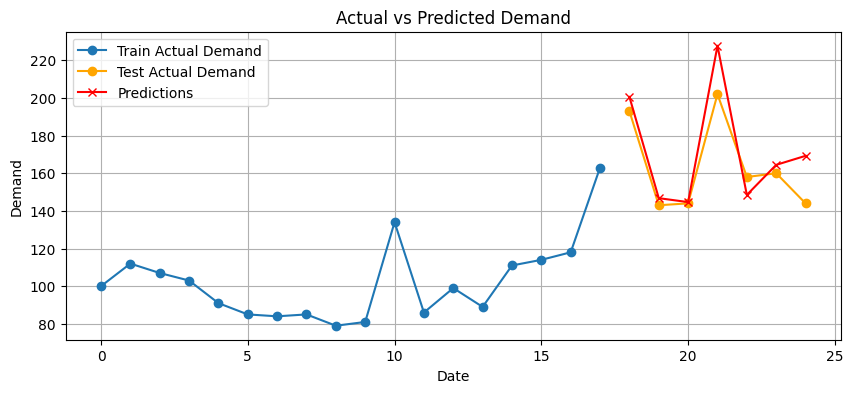

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Data Load
advance_demand = [71, 30, 75, 64, 41, 51, 42, 51, 57, 49, 134, 52, 99, 56, 81, 79, 73, 163, 193, 99, 91, 202, 105, 101, 96]
real_demand = [100, 112, 107, 103, 91, 85, 84, 85, 79, 81, 134, 86, 99, 89, 111, 114, 118, 163, 193, 143, 144, 202, 158, 160, 144]
data = pd.DataFrame({'advance_demand': advance_demand, 'real_demand': real_demand})

# Use the first 18 months for training and the remaining for testing
train_size = 18  

# Splitting the data
train_advance = data['advance_demand'][:train_size]
train_real = data['real_demand'][:train_size]
test_advance = data['advance_demand'][train_size:]
test_real = data['real_demand'][train_size:]

# Using SARIMAX model with added seasonal order
model = SARIMAX(train_real, exog=train_advance, order=(1,1,1), seasonal_order=(1,1,1,5))
model_fit = model.fit(disp=False)

# Print the model summary for diagnostics
print(model_fit.summary())

# Predictions on test data
predictions = model_fit.predict(start=len(train_real), end=len(train_real) + len(test_real) - 1, exog=test_advance)

# Calculate metrics
mae = mean_absolute_error(test_real, predictions)
mse = mean_squared_error(test_real, predictions)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')

# Create the results table
results_df = pd.DataFrame({
    'Month #': np.arange(train_size + 1, train_size + 1 + len(test_real)),
    'Advance Demand': test_advance,
    'Actual Demand': test_real,
    'Predicted Demand': predictions,
    'Delta': test_real - predictions
})

# Display the results table
print(results_df)

# Plot the Actual vs Predicted demand for both train and test sets
plt.figure(figsize=(10, 4))
plt.plot(data.index[:train_size], train_real, label='Train Actual Demand', marker='o')
plt.plot(data.index[train_size:], test_real, label='Test Actual Demand', color='orange', marker='o')
plt.plot(data.index[train_size:], predictions, label='Predictions', color='red', marker='x')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Actual vs Predicted Demand')
plt.legend()
plt.grid(True)
plt.show()
